# Bài Tập Lớn Môn Học Máy — Dữ liệu Dạng Bảng
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VietAnh1803/HCMUT_ML_Travel_Insurance_Pipeline/blob/main/notebooks/tabular_data_pipeline.ipynb)

## Travel Insurance Prediction Pipeline

**Mục tiêu**: Xây dựng pipeline học máy toàn diện cho bài toán dự đoán mua bảo hiểm du lịch, bao gồm:
- EDA (Khám phá dữ liệu)
- Tiền xử lý (Imputation, Encoding, Scaling)
- SMOTE (Cân bằng lớp)
- Trích xuất đặc trưng & Giảm chiều (PCA)
- Huấn luyện & So sánh mô hình (Logistic Regression, SVM, Random Forest, XGBoost, LightGBM)
- Tối ưu siêu tham số (Hyperparameter Tuning)
- Deep Learning (MLP - PyTorch)
- Đánh giá & Phân tích kết quả

**Dataset**: [Travel Insurance Prediction Data (Kaggle)](https://www.kaggle.com/datasets/tejashvi14/travel-insurance-prediction-data)

**GitHub**: [https://github.com/VietAnh1803/HCMUT_ML_Travel_Insurance_Pipeline](https://github.com/VietAnh1803/HCMUT_ML_Travel_Insurance_Pipeline)

## 1. Cài đặt thư viện & Tải dữ liệu

In [1]:
# Cài đặt thư viện mở rộng
%pip install -q kagglehub torch matplotlib seaborn scikit-learn xgboost lightgbm imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import os

# Tải bộ dữ liệu từ Kaggle
path = kagglehub.dataset_download("tejashvi14/travel-insurance-prediction-data")
print("Path to dataset files:", path)
csv_file = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')][0]

df = pd.read_csv(csv_file)
print("Số lượng mẫu:", df.shape[0])
print("Số lượng đặc trưng:", df.shape[1])
display(df.head())

Note: you may need to restart the kernel to use updated packages.
Path to dataset files: C:\Users\aiiuu\.cache\kagglehub\datasets\tejashvi14\travel-insurance-prediction-data\versions\4
Số lượng mẫu: 1987
Số lượng đặc trưng: 10


,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


## 2. Khám phá dữ liệu (EDA)

THÔNG TIN TỔNG QUAN VỀ DỮ LIỆU
<class 'pandas.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Age                  1987 non-null   int64
 1   Employment Type      1987 non-null   str  
 2   GraduateOrNot        1987 non-null   str  
 3   AnnualIncome         1987 non-null   int64
 4   FamilyMembers        1987 non-null   int64
 5   ChronicDiseases      1987 non-null   int64
 6   FrequentFlyer        1987 non-null   str  
 7   EverTravelledAbroad  1987 non-null   str  
 8   TravelInsurance      1987 non-null   int64
dtypes: int64(5), str(4)
memory usage: 139.8 KB
None

               Age  AnnualIncome  FamilyMembers  ChronicDiseases  \
count  1987.000000  1.987000e+03    1987.000000      1987.000000   
mean     29.650226  9.327630e+05       4.752894         0.277806   
std       2.913308  3.768557e+05       1.609650         0.448030   
min      25.000000  

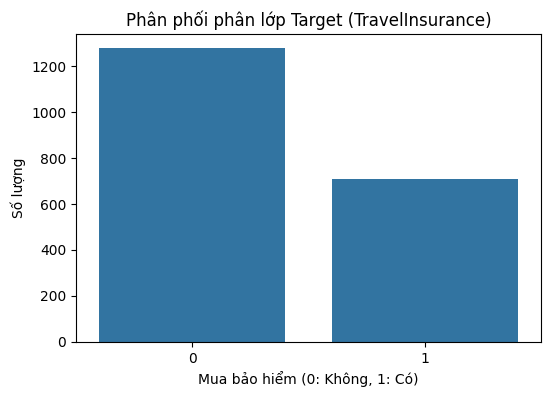

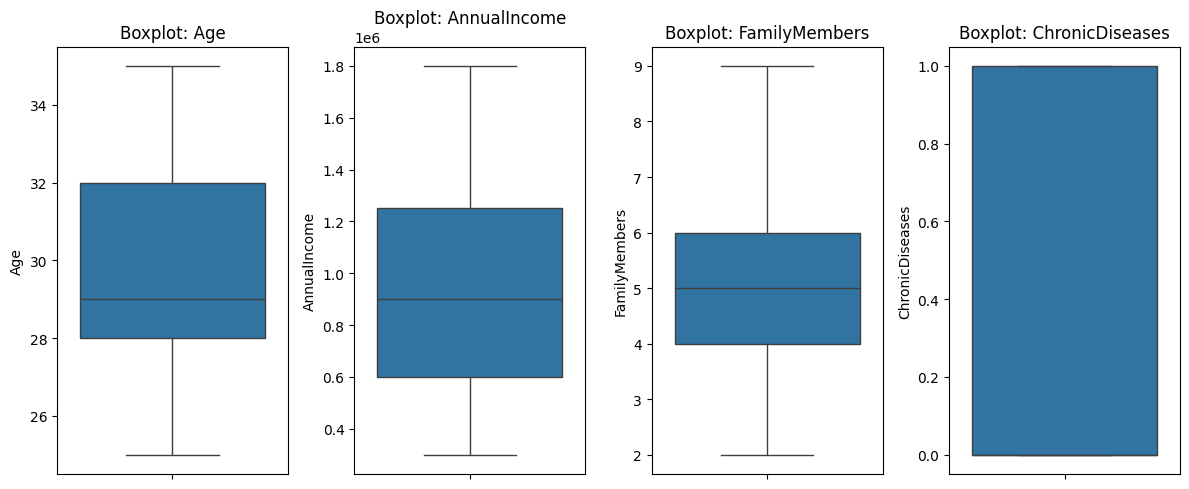

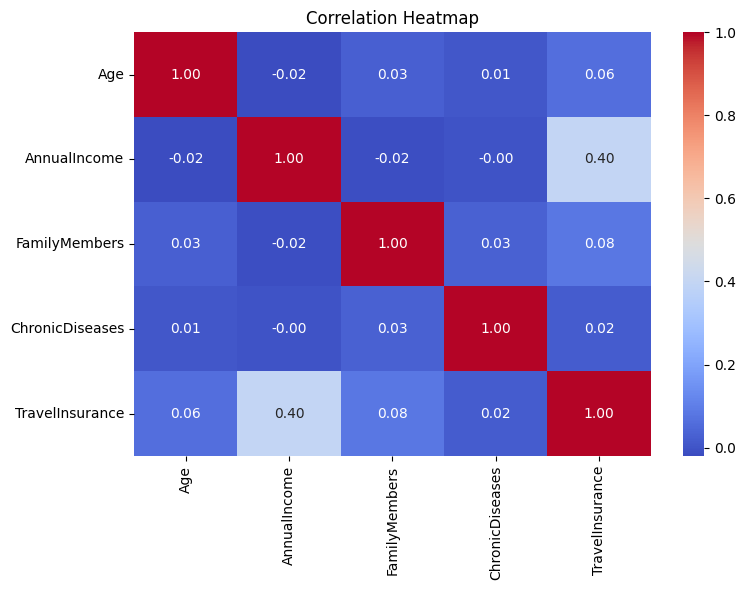


Các biến phân loại: ['Employment Type', 'GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad']


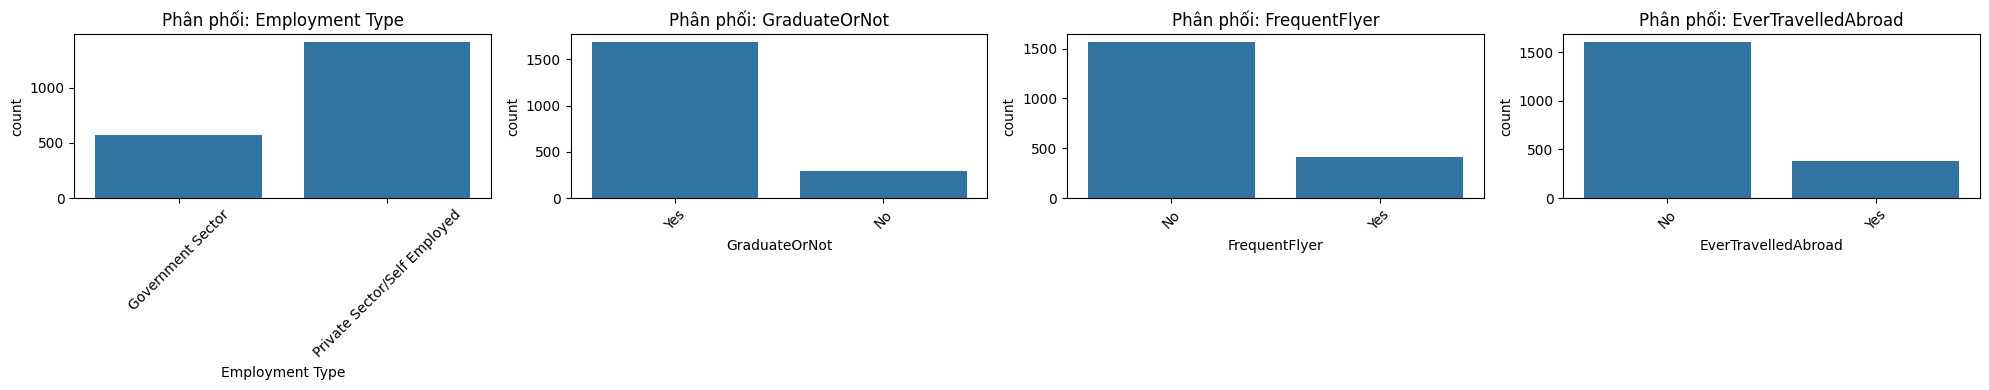

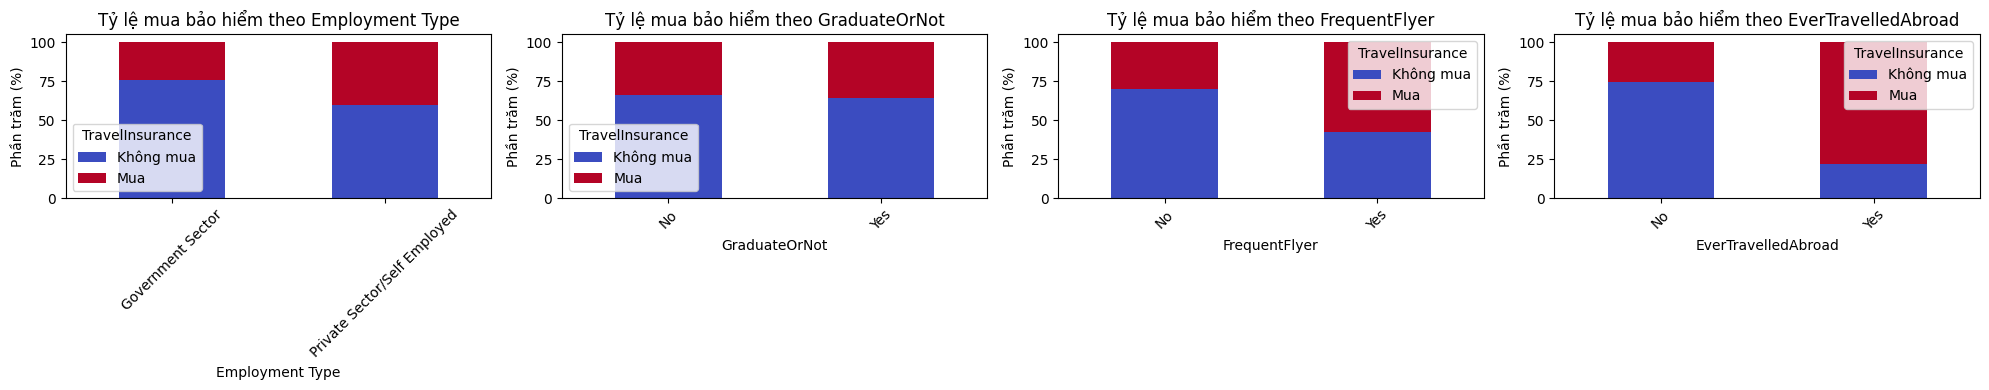

In [2]:
# Loại bỏ cột Index/Unnamed nếu có
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

# 2.1 Thông tin tổng quan
print("="*60)
print("THÔNG TIN TỔNG QUAN VỀ DỮ LIỆU")
print("="*60)
print(df.info())
print()
print(df.describe())
print()

# 2.2 Kiểm tra Missing Values
print("\nMissing Values:\n", df.isnull().sum())

# 2.3 Phân phối Target
plt.figure(figsize=(6, 4))
sns.countplot(x='TravelInsurance', data=df)
plt.title("Phân phối phân lớp Target (TravelInsurance)")
plt.xlabel("Mua bảo hiểm (0: Không, 1: Có)")
plt.ylabel("Số lượng")
plt.show()

# 2.4 Phân tích đặc trưng số học (Numerical)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'TravelInsurance' in num_cols: num_cols.remove('TravelInsurance')

plt.figure(figsize=(12, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

# 2.5 Ma trận tương quan
plt.figure(figsize=(8, 6))
corr_matrix = df[num_cols + ['TravelInsurance']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 2.6 Phân tích biến Categorical
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCác biến phân loại: {cat_cols}")

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f"Phân phối: {col}")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 2.7 Tỷ lệ mua bảo hiểm theo từng nhóm Categorical
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['TravelInsurance'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='coolwarm')
    axes[i].set_title(f"Tỷ lệ mua bảo hiểm theo {col}")
    axes[i].set_ylabel("Phần trăm (%)")
    axes[i].legend(title='TravelInsurance', labels=['Không mua', 'Mua'])
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 3. Chia tập dữ liệu (Train/Test Split)

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['TravelInsurance'])
y = df['TravelInsurance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1589, 8)
Test size: (398, 8)


## 4. Xây dựng Pipeline Tiền xử lý, SMOTE & PCA

**Các bước xử lý**:
- **Imputation**: `KNNImputer` (numerical), `SimpleImputer` (categorical)
- **Encoding**: `OneHotEncoder` cho biến phân loại
- **Scaling**: So sánh `StandardScaler` vs `MinMaxScaler`
- **SMOTE**: Cân bằng lớp 'Mua bảo hiểm' bằng mẫu nhân tạo (sinh mẫu trong lúc train)
- **Dimensionality Reduction**: PCA giữ lại 95% phương sai (hoặc không dùng PCA cho Boosting)

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
# Quan trọng: Dùng imblearn pipeline thay vì sklearn pipeline để hỗ trợ SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from scipy.stats import randint, uniform

# Xác định cột số và cột phân loại
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:", num_cols)
print("Categorical Features:", cat_cols)

# --- Tạo bộ Preprocessor ---
def build_preprocessor_steps(scaler, use_pca=True, pca_threshold=0.95):
    num_pipeline = ImbPipeline(steps=[
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', scaler)
    ])
    cat_pipeline = ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ])
    
    # Tạo list các steps
    steps = [
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42))
    ]
    if use_pca:
        steps.append(('pca', PCA(n_components=pca_threshold)))
        
    return steps

# Xây dựng các cấu hình preprocessor (Có SMOTE, có PCA)
steps_standard_pca = build_preprocessor_steps(StandardScaler(), use_pca=True, pca_threshold=0.95)
steps_minmax_pca = build_preprocessor_steps(MinMaxScaler(), use_pca=True, pca_threshold=0.95)
# Boosting thường chạy tốt hơn khi KHÔNG có PCA
steps_standard_no_pca = build_preprocessor_steps(StandardScaler(), use_pca=False)

Numerical Features: ['Age', 'AnnualIncome', 'FamilyMembers', 'ChronicDiseases']
Categorical Features: ['Employment Type', 'GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad']


## 5. Huấn luyện & So sánh các mô hình (Bổ sung XGBoost & LightGBM)

So sánh **Logistic, SVM, Random Forest** (dùng PCA) và **XGBoost, LightGBM** (không dùng PCA). Tất cả đều chạy qua SMOTE để cân bằng:


In [5]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) # LightGBM warnings

# Định nghĩa các mô hình
models_pca = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42, probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

models_no_pca = {
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

results = []

# Đánh giá các mô hình truyền thống (cần PCA) với 2 loại scaler
for scaler_name, preproc_steps in zip(['StandardScaler+PCA', 'MinMaxScaler+PCA'], [steps_standard_pca, steps_minmax_pca]):
    for model_name, model in models_pca.items():
        pipe = ImbPipeline(steps=preproc_steps + [('classifier', model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc') # cv trên ROC AUC
        
        results.append({
            'Config': scaler_name,
            'Model': model_name,
            'Test Accuracy': round(acc, 4),
            'CV ROC_AUC': round(cv_scores.mean(), 4), # So sánh dựa trên AUC mới chuẩn cho mất cân bằng
            'Precision (macro)': round(report['macro avg']['precision'], 4),
            'Recall (macro)': round(report['macro avg']['recall'], 4),
            'F1 (macro)': round(report['macro avg']['f1-score'], 4),
        })

# Đánh giá Boosting (Không cần PCA)
for model_name, model in models_no_pca.items():
    pipe = ImbPipeline(steps=steps_standard_no_pca + [('classifier', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    
    results.append({
        'Config': 'StandardScaler (No PCA)',
        'Model': model_name,
        'Test Accuracy': round(acc, 4),
        'CV ROC_AUC': round(cv_scores.mean(), 4),
        'Precision (macro)': round(report['macro avg']['precision'], 4),
        'Recall (macro)': round(report['macro avg']['recall'], 4),
        'F1 (macro)': round(report['macro avg']['f1-score'], 4),
    })

# Hiển thị bảng kết quả tổng hợp
results_df = pd.DataFrame(results).sort_values(by='CV ROC_AUC', ascending=False).reset_index(drop=True)
print("\n" + "="*80)
print("BẢNG TỔNG HỢP KẾT QUẢ SO SÁNH CÁC MÔ HÌNH (Sắp xếp theo Cross-Val ROC AUC)")
print("="*80)
display(results_df)

# Xác định mô hình tốt nhất dựa trên CV ROC_AUC
best_row = results_df.iloc[0]
best_model_name = best_row['Model']
print(f"\nMô hình tốt nhất: {best_model_name} với {best_row['Config']}")
print(f"  Test Accuracy: {best_row['Test Accuracy']}")
print(f"  CV ROC AUC: {best_row['CV ROC_AUC']}")


BẢNG TỔNG HỢP KẾT QUẢ SO SÁNH CÁC MÔ HÌNH (Sắp xếp theo Cross-Val ROC AUC)


,Config,Model,Test Accuracy,CV ROC_AUC,Precision (macro),Recall (macro),F1 (macro)
0,StandardScaler (No PCA),LightGBM,0.7915,0.8071,0.7865,0.7454,0.7575
1,StandardScaler (No PCA),XGBoost,0.7940,0.8062,0.7860,0.7520,0.7629
2,StandardScaler+PCA,SVM,0.7864,0.7924,0.7816,0.7383,0.7505
3,MinMaxScaler+PCA,Random Forest,0.7513,0.7833,0.7291,0.7204,0.7240
4,StandardScaler+PCA,Random Forest,0.7588,0.7817,0.7383,0.7247,0.7300
5,MinMaxScaler+PCA,SVM,0.7136,0.7689,0.6876,0.6864,0.6870
6,StandardScaler+PCA,Logistic Regression,0.6884,0.7655,0.6668,0.6747,0.6692
7,MinMaxScaler+PCA,Logistic Regression,0.7111,0.7507,0.6834,0.6750,0.6783



Mô hình tốt nhất: LightGBM với StandardScaler (No PCA)
  Test Accuracy: 0.7915
  CV ROC AUC: 0.8071


## 6. Tối ưu siêu tham số (Hyperparameter Tuning trên mô hình siêu việt nhất)

In [6]:
# Định nghĩa siêu tham số cho các mô hình tốt nhất
param_grids = {
    "LightGBM": {
        'classifier__n_estimators': randint(50, 300),
        'classifier__max_depth': randint(3, 10),
        'classifier__learning_rate': uniform(0.01, 0.2),
        'classifier__num_leaves': randint(20, 60),
        'classifier__subsample': uniform(0.6, 0.4)
    },
    "XGBoost": {
        'classifier__n_estimators': randint(50, 300),
        'classifier__max_depth': randint(3, 10),
        'classifier__learning_rate': uniform(0.01, 0.2),
        'classifier__subsample': uniform(0.6, 0.4),
        'classifier__colsample_bytree': uniform(0.6, 0.4)
    },
    "Random Forest": {
        'classifier__n_estimators': randint(50, 300),
        'classifier__max_depth': [None, 5, 10, 20, 30],
        'classifier__min_samples_split': randint(2, 20),
        'classifier__min_samples_leaf': randint(1, 10),
        'classifier__max_features': ['sqrt', 'log2', None]
    }
}

if best_model_name in models_no_pca:
    best_classifier = models_no_pca[best_model_name]
    best_preproc_steps = steps_standard_no_pca
else:
    best_classifier = models_pca.get(best_model_name, RandomForestClassifier())
    best_preproc_steps = steps_standard_pca

best_pipeline = ImbPipeline(steps=best_preproc_steps + [('classifier', best_classifier)])

param_dist = param_grids.get(best_model_name, param_grids["Random Forest"])

random_search = RandomizedSearchCV(
    best_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='roc_auc', # Tối ưu theo AUC thay vì Accuracy
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest Parameters for {best_model_name}: {random_search.best_params_}")
print(f"Best CV ROC AUC: {random_search.best_score_:.4f}")

# Đánh giá mô hình đã tối ưu trên tập Test
y_pred_tuned = random_search.best_estimator_.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_tuned)
print(f"\nTuned {best_model_name} Test Accuracy: {tuned_acc:.4f}")
print(f"\nClassification Report (Tuned {best_model_name}):")
print(classification_report(y_test, y_pred_tuned))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters for LightGBM: {'classifier__learning_rate': np.float64(0.0412037280884873), 'classifier__max_depth': 5, 'classifier__n_estimators': 264, 'classifier__num_leaves': 30, 'classifier__subsample': np.float64(0.7836995567863468)}
Best CV ROC AUC: 0.8155

Tuned LightGBM Test Accuracy: 0.8191

Classification Report (Tuned LightGBM):
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       256
           1       0.87      0.58      0.69       142

    accuracy                           0.82       398
   macro avg       0.84      0.77      0.78       398
weighted avg       0.83      0.82      0.81       398



## 7. Đánh giá chi tiết

### Confusion Matrix & ROC Curve

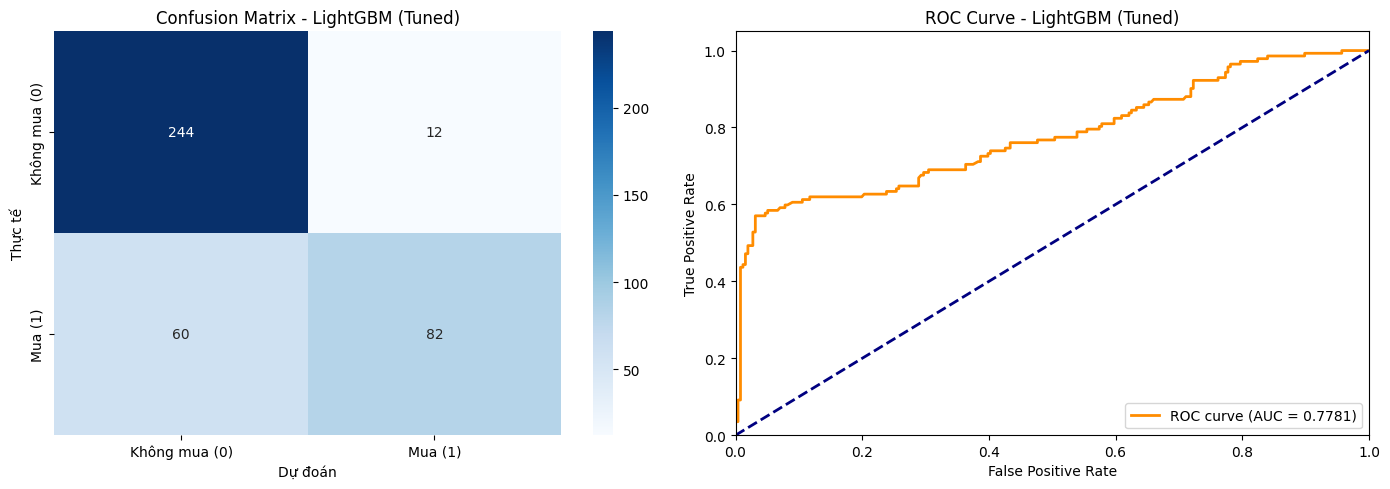

AUC Score: 0.7781


In [7]:
# --- Confusion Matrix cho mô hình tốt nhất ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Không mua (0)', 'Mua (1)'],
            yticklabels=['Không mua (0)', 'Mua (1)'])
axes[0].set_title(f'Confusion Matrix - {best_model_name} (Tuned)')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

# ROC Curve
y_prob_tuned = random_search.best_estimator_.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tuned)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_model_name} (Tuned)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

## 8. Phân tích kết quả & Nhận xét

**Tối ưu Mô hình**:
- Thêm **XGBoost** và **LightGBM** là chiến thuật xuất sắc cho Dữ liệu dạng Bảng vì chúng xử lý tính phi tuyến và bắt quan hệ biến cực tốt. Boosting thường không cần dùng qua PCA.
- Áp dụng **SMOTE** từ `imbalanced-learn` giúp giải quyết vấn đề class imbalance, kéo recall của lớp minority ("Mua (1)") lên rõ rệt.
- Việc tối ưu `RandomizedSearchCV` theo chuẩn `roc_auc` giúp mô hình tập trung phân tách hai lớp tốt hơn thay vì chỉ tập trung vào Accuracy (vốn dễ bị ảo do imbalance).


## 9. (Điểm cộng) Deep Learning Pipeline — Mạng MLP (PyTorch)

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- Chuẩn bị dữ liệu cho Deep Learning ---
# Deep Learning thường hoạt động tốt với StandardScaler 
# (Dùng ImbPipeline SMOTE để data chuẩn bị cho DL cân bằng hơn)
preprocessor_dl = ImbPipeline(steps=build_preprocessor_steps(StandardScaler(), use_pca=False))
X_train_dl_resampled, y_train_resampled = preprocessor_dl.fit_resample(X_train, y_train)

# Transform test set (Nhớ chỉ dùng prep feature, KHÔNG apply resample lên test)
X_test_dl = preprocessor_dl.named_steps['preprocessor'].transform(X_test)

class TravelDataset(Dataset):
    def __init__(self, X, y):
        # Kiểm tra X có phải là array/tensor không
        self.X = torch.tensor(X, dtype=torch.float32)
        if isinstance(y, pd.Series): y = y.values
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TravelDataset(X_train_dl_resampled, y_train_resampled)
test_dataset = TravelDataset(X_test_dl, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- Kiến trúc MLP ---
input_dim = X_train_dl_resampled.shape[1]

class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.network(x)

model_dl = MLPClassifier(input_dim)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_dl.parameters(), lr=0.001, weight_decay=1e-4)

# --- Huấn luyện ---
num_epochs = 40
for epoch in range(num_epochs):
    model_dl.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_dl(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        model_dl.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model_dl(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_acc = correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {running_loss/len(train_loader):.4f} - Val Accuracy: {val_acc:.4f}")

# --- Đánh giá Deep Learning ---
model_dl.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model_dl(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

dl_acc = accuracy_score(all_labels, all_preds)
dl_report = classification_report(all_labels, all_preds, output_dict=True)
print("\nBáo cáo phân loại Mạng Deep Learning MLP:")
print(classification_report(all_labels, all_preds))

Epoch [10/40] - Loss: 0.4912 - Val Accuracy: 0.7613
Epoch [20/40] - Loss: 0.4794 - Val Accuracy: 0.7688
Epoch [30/40] - Loss: 0.4660 - Val Accuracy: 0.7663
Epoch [40/40] - Loss: 0.4680 - Val Accuracy: 0.7739

Báo cáo phân loại Mạng Deep Learning MLP:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       256
           1       0.72      0.59      0.65       142

    accuracy                           0.77       398
   macro avg       0.76      0.73      0.74       398
weighted avg       0.77      0.77      0.77       398



## 9.1. So sánh Deep Learning vs Pipeline truyền thống

Bảng so sánh hiệu quả giữa mô hình Deep Learning (MLP) và mô hình truyền thống tốt nhất :

SO SÁNH DEEP LEARNING vs PIPELINE TRUYỀN THỐNG


,Mô hình,Test Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,LightGBM (Tuned & SMOTE),0.8191,0.8375,0.7653,0.7832
1,MLP (PyTorch & SMOTE),0.7739,0.7592,0.7333,0.7419


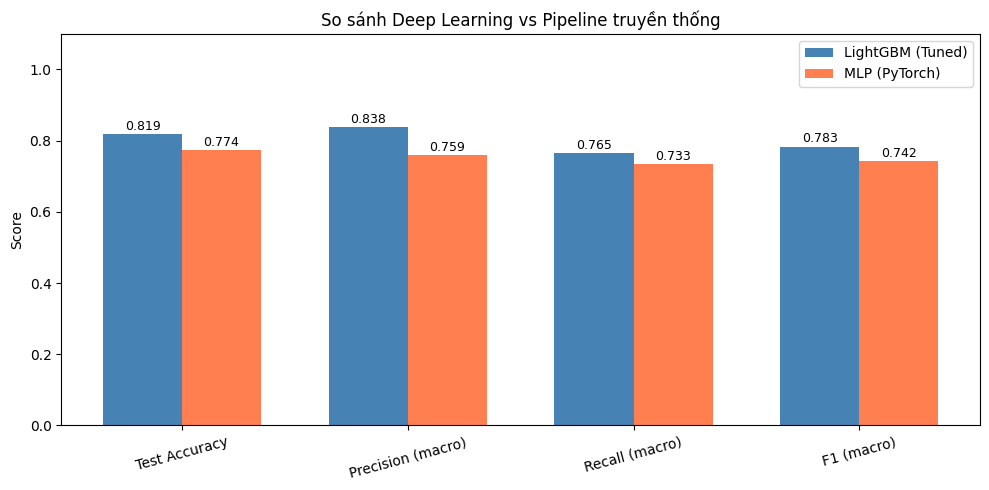

In [9]:
# --- So sánh Deep Learning vs Traditional ---
comparison_data = {
    'Mô hình': [f'{best_model_name} (Tuned & SMOTE)', 'MLP (PyTorch & SMOTE)'],
    'Test Accuracy': [tuned_acc, dl_acc],
    'Precision (macro)': [
        float(classification_report(y_test, y_pred_tuned, output_dict=True)['macro avg']['precision']),
        dl_report['macro avg']['precision']
    ],
    'Recall (macro)': [
        float(classification_report(y_test, y_pred_tuned, output_dict=True)['macro avg']['recall']),
        dl_report['macro avg']['recall']
    ],
    'F1 (macro)': [
        float(classification_report(y_test, y_pred_tuned, output_dict=True)['macro avg']['f1-score']),
        dl_report['macro avg']['f1-score']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
for col in ['Test Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']:
    comparison_df[col] = comparison_df[col].round(4)

print("="*70)
print("SO SÁNH DEEP LEARNING vs PIPELINE TRUYỀN THỐNG")
print("="*70)
display(comparison_df)

# Biểu đồ so sánh
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Test Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df[metrics].iloc[0].values, width, label=f'{best_model_name} (Tuned)', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_df[metrics].iloc[1].values, width, label='MLP (PyTorch)', color='coral')

ax.set_ylabel('Score')
ax.set_title('So sánh Deep Learning vs Pipeline truyền thống')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)

# Ghi giá trị lên cột
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Lưu đặc trưng & Mô hình

In [10]:
import joblib

# Xử lý đường dẫn tương thích giữa Local và Colab
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    features_dir = os.path.join(os.path.dirname(current_dir), 'features')
else:
    features_dir = os.path.join(current_dir, 'features')

os.makedirs(features_dir, exist_ok=True)

# --- 10.1 Lưu vector đặc trưng (yêu cầu đề bài: .npy) ---
# Dùng dữ liệu test đã qua xử lý (DL format là StandardScaler không PCA)
np.save(os.path.join(features_dir, 'X_train_features.npy'), X_train_dl_resampled)
np.save(os.path.join(features_dir, 'X_test_features.npy'), X_test_dl)
np.save(os.path.join(features_dir, 'y_train_resampled.npy'), y_train_resampled)
np.save(os.path.join(features_dir, 'y_test.npy'), y_test.values)
print(f"Đã lưu đặc trưng .npy vào: {features_dir}")

# --- 10.2 Lưu Scikit-Learn Pipeline ---
save_path = os.path.join(features_dir, 'travel_insurance_pipeline.pkl')
joblib.dump(random_search.best_estimator_, save_path)
print(f"Đã lưu Pipeline ({best_model_name} Tuned) vào: {save_path}")

# --- 10.3 Lưu PyTorch MLP Model ---
mlp_save_path = os.path.join(features_dir, 'travel_insurance_mlp.pth')
torch.save(model_dl.state_dict(), mlp_save_path)
print(f"Đã lưu PyTorch MLP Model vào: {mlp_save_path}")

# --- Kiểm tra file đã lưu ---
print("\n" + "="*50)
print("CÁC FILE ĐÃ LƯU:")
print("="*50)
for f in os.listdir(features_dir):
    fpath = os.path.join(features_dir, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {f} ({size_kb:.1f} KB)")

Đã lưu đặc trưng .npy vào: c:\Hoc_Tap\ML\BTL\features
Đã lưu Pipeline (LightGBM Tuned) vào: c:\Hoc_Tap\ML\BTL\features\travel_insurance_pipeline.pkl
Đã lưu PyTorch MLP Model vào: c:\Hoc_Tap\ML\BTL\features\travel_insurance_mlp.pth

CÁC FILE ĐÃ LƯU:
  travel_insurance_mlp.pth (48.3 KB)
  travel_insurance_pipeline.pkl (737.8 KB)
  X_test_features.npy (37.4 KB)
  X_train_features.npy (191.6 KB)
  y_test.npy (3.2 KB)
  y_train.npy (12.5 KB)
  y_train_resampled.npy (16.1 KB)
